<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/08_Final_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 — Final Validation Comparison: ARCH vs Deep Learning

This notebook consolidates the **validation-period** error metrics from:

- Daily variance baselines
- ARCH-family models
- Global multi-asset MLP / GRU / LSTM models
- BTC-only standalone MLP / GRU / LSTM models across 7d / 14d / 30d lookbacks

The common forecast target is the next-day daily squared log return:

\[
r_{t+1}^2
\]

Model ranking uses **QLIKE as the primary volatility-forecasting metric**, with MAE and RMSE reported as complementary error measures.

### Important scope
This notebook compares **validation results only**. It does not evaluate or open the untouched test set.

## 1. Imports and project paths

In [1]:
from google.colab import drive
from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Quant Research"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

FINAL_DIR = (
    RESULTS_DIR
    / "FINAL_MODEL_COMPARISON"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

GLOBAL_COMPARISON_PATH = (
    RESULTS_DIR
    / "GLOBAL_4_ASSETS"
    / "final_validation_comparison_by_asset.csv"
)

# The most recent collaborator workflow used this location.
# A fallback is retained for compatibility with the earlier ARCH comparison notebook.
ARCH_METRIC_CANDIDATES = [
    RESULTS_DIR
    / "arch_family"
    / "arch_validation_metrics.csv",

    RESULTS_DIR
    / "ARCH_FAMILY"
    / "daily_returns"
    / "validation"
    / "arch_validation_metrics_by_asset.csv",
]

BTC_BASELINE_PATH = (
    RESULTS_DIR
    / "BTCUSDT"
    / "baseline_validation_metrics.csv"
)

print("Project:", PROJECT_DIR)
print("Final comparison outputs:", FINAL_DIR)

Mounted at /content/drive
Project: /content/drive/MyDrive/Quant Research
Final comparison outputs: /content/drive/MyDrive/Quant Research/results/FINAL_MODEL_COMPARISON


## 2. Helper functions

These helpers standardize column names and asset labels across the independently developed ARCH and deep-learning pipelines.

In [2]:
ASSET_MAP = {
    "BTC": "BTCUSDT",
    "BTCUSDT": "BTCUSDT",
    "ETH": "ETHUSDT",
    "ETHUSDT": "ETHUSDT",
    "SOL": "SOLUSDT",
    "SOLUSDT": "SOLUSDT",
    "XRP": "XRPUSDT",
    "XRPUSDT": "XRPUSDT",
    "ALL_ASSETS": "ALL_ASSETS",
}

CORE_ASSETS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

BASELINE_MODELS = {
    "Persistence",
    "7-Day Mean RV",
    "30-Day Mean RV",
}

def normalize_asset(value):
    if pd.isna(value):
        return value
    key = str(value).strip().upper()
    return ASSET_MAP.get(key, key)


def normalize_metric_frame(
    df,
    *,
    source_scope,
    default_asset=None,
):
    out = df.copy()

    # Normalize column names while preserving model labels.
    out.columns = [
        str(c).strip().lower()
        for c in out.columns
    ]

    rename_candidates = {
        "observations": "n_observations",
        "n_validation": "n_observations",
        "n_val": "n_observations",
        "n_test": "n_observations",
        "asset_name": "asset",
        "symbol": "asset",
        "model_name": "model",
    }

    out = out.rename(
        columns={
            k: v
            for k, v in rename_candidates.items()
            if k in out.columns
        }
    )

    if "asset" not in out.columns:
        if default_asset is None:
            raise ValueError(
                "Metric file has no asset column "
                "and no default asset was supplied."
            )
        out["asset"] = default_asset

    if "model" not in out.columns:
        raise ValueError(
            "Metric file is missing a model column."
        )

    required_metrics = [
        "mae",
        "rmse",
        "qlike",
    ]

    missing_metrics = [
        c
        for c in required_metrics
        if c not in out.columns
    ]

    if missing_metrics:
        raise ValueError(
            f"Missing metric columns: {missing_metrics}"
        )

    if "n_observations" not in out.columns:
        out["n_observations"] = np.nan

    out["asset"] = (
        out["asset"]
        .map(normalize_asset)
    )

    for col in [
        "mae",
        "rmse",
        "qlike",
        "n_observations",
    ]:
        out[col] = pd.to_numeric(
            out[col],
            errors="coerce",
        )

    out["source_scope"] = source_scope
    out["evaluation_set"] = "validation"

    return out[
        [
            "asset",
            "model",
            "source_scope",
            "evaluation_set",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
        ]
    ].copy()


def model_family(model, source_scope):
    name = str(model)

    if name in BASELINE_MODELS:
        return "Baseline"

    if (
        "GARCH" in name.upper()
        or "EGARCH" in name.upper()
        or source_scope == "ARCH"
    ):
        return "ARCH"

    if source_scope == "Global DL":
        return "Deep Learning — Global"

    if source_scope == "BTC Standalone DL":
        return "Deep Learning — BTC Standalone"

    return source_scope


def architecture_name(model):
    name = str(model).upper()

    if "GJR-GARCH" in name:
        return "GJR-GARCH"
    if "EGARCH" in name:
        return "EGARCH"
    if "GARCH" in name:
        return "GARCH"
    if "MLP" in name:
        return "MLP"
    if "GRU" in name:
        return "GRU"
    if "LSTM" in name:
        return "LSTM"
    if model in BASELINE_MODELS:
        return "Baseline"

    return str(model)


def extract_lookback(model):
    match = re.search(
        r"(\d+)d",
        str(model),
        flags=re.IGNORECASE,
    )

    if match is None:
        return np.nan

    return int(match.group(1))


def find_existing_path(candidates, label):
    existing = [
        p
        for p in candidates
        if p.exists()
    ]

    if not existing:
        candidate_text = "\n".join(
            str(p)
            for p in candidates
        )

        raise FileNotFoundError(
            f"{label} was not found. Checked:\n"
            f"{candidate_text}"
        )

    selected = existing[0]

    print(
        f"{label}:\n{selected}"
    )

    return selected

## 3. Load global deep-learning models and daily baselines

The latest global notebook already saves one common table containing:

- Global MLP-30d
- Global GRU-7d
- Global LSTM-14d
- Persistence
- 7-Day Mean RV
- 30-Day Mean RV

for BTC, ETH, SOL and XRP.

In [3]:
if not GLOBAL_COMPARISON_PATH.exists():
    raise FileNotFoundError(
        "Global comparison file not found:\n"
        f"{GLOBAL_COMPARISON_PATH}\n\n"
        "Run the latest global multi-asset notebook first."
    )

global_raw_df = pd.read_csv(
    GLOBAL_COMPARISON_PATH
)

global_normalized_df = normalize_metric_frame(
    global_raw_df,
    source_scope="Global DL / Baseline",
)

global_normalized_df["source_scope"] = np.where(
    global_normalized_df["model"].isin(
        BASELINE_MODELS
    ),
    "Baseline",
    "Global DL",
)

display(
    global_normalized_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

,asset,model,source_scope,evaluation_set,n_observations,mae,rmse,qlike
0,ALL_ASSETS,Global-LSTM-14d,Global DL,validation,1460,0.001522,0.004861,4.652908
1,ALL_ASSETS,Global-GRU-7d,Global DL,validation,1460,0.001521,0.004875,4.782429
2,ALL_ASSETS,Global-MLP-30d,Global DL,validation,1460,0.001532,0.004896,4.806985
3,BTCUSDT,30-Day Mean RV,Baseline,validation,365,0.000731,0.001355,1.878815
4,BTCUSDT,7-Day Mean RV,Baseline,validation,365,0.000768,0.001377,2.160473
5,BTCUSDT,Global-MLP-30d,Global DL,validation,365,0.000573,0.001405,3.751286
6,BTCUSDT,Global-LSTM-14d,Global DL,validation,365,0.000572,0.001416,4.667831
7,BTCUSDT,Global-GRU-7d,Global DL,validation,365,0.000581,0.001419,4.824585
8,BTCUSDT,Persistence,Baseline,validation,365,0.000892,0.001800,1878.685363
9,ETHUSDT,30-Day Mean RV,Baseline,validation,365,0.001823,0.003553,1.855280


## 4. Load ARCH-family validation metrics

All ARCH-family rows are normalized to the same asset labels used by the DL pipeline.

In [4]:
ARCH_METRICS_PATH = find_existing_path(
    ARCH_METRIC_CANDIDATES,
    "ARCH validation metrics",
)

arch_raw_df = pd.read_csv(
    ARCH_METRICS_PATH
)

arch_normalized_df = normalize_metric_frame(
    arch_raw_df,
    source_scope="ARCH",
)

display(
    arch_normalized_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

ARCH validation metrics:
/content/drive/MyDrive/Quant Research/results/arch_family/arch_validation_metrics.csv


,asset,model,source_scope,evaluation_set,n_observations,mae,rmse,qlike
0,BTCUSDT,"GARCH(1,1)",ARCH,validation,365,0.000820,0.001353,1.865873
1,BTCUSDT,"GJR-GARCH(1,1)",ARCH,validation,365,0.000818,0.001356,1.871827
2,BTCUSDT,"EGARCH(1,1)",ARCH,validation,365,0.000973,0.001434,1.943311
3,ETHUSDT,"GARCH(1,1)",ARCH,validation,365,0.002023,0.003583,1.855979
4,ETHUSDT,"GJR-GARCH(1,1)",ARCH,validation,365,0.002013,0.003583,1.856590
5,ETHUSDT,"EGARCH(1,1)",ARCH,validation,365,0.002044,0.003580,1.878446
6,SOLUSDT,"GARCH(1,1)",ARCH,validation,365,0.002616,0.004815,1.650260
7,SOLUSDT,"GJR-GARCH(1,1)",ARCH,validation,365,0.002614,0.004811,1.650744
8,SOLUSDT,"EGARCH(1,1)",ARCH,validation,365,0.002587,0.004786,1.657325
9,XRPUSDT,"EGARCH(1,1)",ARCH,validation,365,0.003402,0.007040,1.914143


## 5. Load all BTC-only standalone DL runs

This retains the complete BTC experiment history:

- MLP: 7d / 14d / 30d
- GRU: 7d / 14d / 30d
- LSTM: 7d / 14d / 30d

In [5]:
BTC_DL_FILES = []

for lookback in [
    7,
    14,
    30,
]:

    for architecture, filename in [
        (
            "MLP",
            "mlp_validation_metrics.csv",
        ),
        (
            "GRU",
            "gru_validation_metrics.csv",
        ),
        (
            "LSTM",
            "lstm_validation_metrics.csv",
        ),
    ]:

        path = (
            RESULTS_DIR
            / "BTCUSDT"
            / f"lookback_{lookback}d"
            / architecture
            / filename
        )

        BTC_DL_FILES.append(
            (
                architecture,
                lookback,
                path,
            )
        )


missing_btc_files = [
    str(path)
    for _, _, path
    in BTC_DL_FILES
    if not path.exists()
]

if missing_btc_files:
    raise FileNotFoundError(
        "Some BTC standalone DL metric files "
        "are missing:\n"
        + "\n".join(
            missing_btc_files
        )
    )


btc_frames = []

for (
    architecture,
    lookback,
    path,
) in BTC_DL_FILES:

    current = pd.read_csv(path)

    current = normalize_metric_frame(
        current,
        source_scope="BTC Standalone DL",
        default_asset="BTCUSDT",
    )

    # Keep the saved model label, but enforce a clear label
    # if an older result file contains only the architecture name.
    current["model"] = current["model"].astype(str)

    if not current["model"].str.contains(
        f"{lookback}d",
        case=False,
        regex=False,
    ).all():

        current["model"] = (
            architecture
            + "-"
            + str(lookback)
            + "d"
        )

    btc_frames.append(
        current
    )


btc_standalone_df = pd.concat(
    btc_frames,
    ignore_index=True,
)

display(
    btc_standalone_df
    .sort_values(
        [
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

,asset,model,source_scope,evaluation_set,n_observations,mae,rmse,qlike
0,BTCUSDT,MLP-30d,BTC Standalone DL,validation,NaN,0.000592,0.001397,4.627228
1,BTCUSDT,LSTM-14d,BTC Standalone DL,validation,NaN,0.000575,0.001417,4.738927
2,BTCUSDT,LSTM-7d,BTC Standalone DL,validation,NaN,0.000580,0.001421,4.832544
3,BTCUSDT,GRU-7d,BTC Standalone DL,validation,NaN,0.000579,0.001415,4.925452
4,BTCUSDT,GRU-14d,BTC Standalone DL,validation,NaN,0.000582,0.001434,5.248540
5,BTCUSDT,LSTM-30d,BTC Standalone DL,validation,NaN,0.000582,0.001434,5.361597
6,BTCUSDT,GRU-30d,BTC Standalone DL,validation,NaN,0.000584,0.001436,5.515649
7,BTCUSDT,MLP-7d,BTC Standalone DL,validation,NaN,0.000589,0.001419,6.082799
8,BTCUSDT,MLP-14d,BTC Standalone DL,validation,NaN,0.000589,0.001407,6.853991


## 6. Build the unified validation comparison

The unified table contains every currently relevant result while preserving model scope:

- Baselines
- ARCH
- Global DL
- BTC-only standalone DL

In [6]:
all_metrics_df = pd.concat(
    [
        global_normalized_df,
        arch_normalized_df,
        btc_standalone_df,
    ],
    ignore_index=True,
)

all_metrics_df = (
    all_metrics_df
    .dropna(
        subset=[
            "asset",
            "model",
            "mae",
            "rmse",
            "qlike",
        ]
    )
    .drop_duplicates(
        subset=[
            "asset",
            "model",
            "source_scope",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

all_metrics_df["model_family"] = [
    model_family(
        model,
        scope,
    )
    for model, scope
    in zip(
        all_metrics_df["model"],
        all_metrics_df["source_scope"],
    )
]

all_metrics_df["architecture"] = (
    all_metrics_df["model"]
    .map(architecture_name)
)

all_metrics_df["lookback_days"] = (
    all_metrics_df["model"]
    .map(extract_lookback)
)

# Rank only within the same asset.
all_metrics_df[
    "qlike_rank_within_asset"
] = (
    all_metrics_df
    .groupby("asset")["qlike"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

all_metrics_df[
    "mae_rank_within_asset"
] = (
    all_metrics_df
    .groupby("asset")["mae"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

all_metrics_df[
    "rmse_rank_within_asset"
] = (
    all_metrics_df
    .groupby("asset")["rmse"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

all_metrics_df = (
    all_metrics_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

ALL_METRICS_PATH = (
    FINAL_DIR
    / "all_validation_model_metrics.csv"
)

all_metrics_df.to_csv(
    ALL_METRICS_PATH,
    index=False,
)

display(
    all_metrics_df.style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
        "lookback_days": "{:.0f}",
    })
)

print(
    "Saved:",
    ALL_METRICS_PATH,
)

,asset,model,source_scope,evaluation_set,n_observations,mae,rmse,qlike,model_family,architecture,lookback_days,qlike_rank_within_asset,mae_rank_within_asset,rmse_rank_within_asset
0,ALL_ASSETS,Global-LSTM-14d,Global DL,validation,1460.000000,0.00152244,0.00486096,4.652908,Deep Learning — Global,LSTM,14,1,2,1
1,ALL_ASSETS,Global-GRU-7d,Global DL,validation,1460.000000,0.00152112,0.00487545,4.782429,Deep Learning — Global,GRU,7,2,1,2
2,ALL_ASSETS,Global-MLP-30d,Global DL,validation,1460.000000,0.00153246,0.00489632,4.806985,Deep Learning — Global,MLP,30,3,3,3
3,BTCUSDT,"GARCH(1,1)",ARCH,validation,365.000000,0.00082004,0.00135341,1.865873,ARCH,GARCH,nan,1,16,1
4,BTCUSDT,"GJR-GARCH(1,1)",ARCH,validation,365.000000,0.00081828,0.00135638,1.871827,ARCH,GJR-GARCH,nan,2,15,3
5,BTCUSDT,30-Day Mean RV,Baseline,validation,365.000000,0.00073064,0.00135501,1.878815,Baseline,Baseline,nan,3,13,2
6,BTCUSDT,"EGARCH(1,1)",ARCH,validation,365.000000,0.00097334,0.00143367,1.943311,ARCH,EGARCH,nan,4,18,16
7,BTCUSDT,7-Day Mean RV,Baseline,validation,365.000000,0.00076783,0.00137714,2.160473,Baseline,Baseline,nan,5,14,4
8,BTCUSDT,Global-MLP-30d,Global DL,validation,365.000000,0.00057313,0.00140498,3.751286,Deep Learning — Global,MLP,30,6,2,6
9,BTCUSDT,MLP-30d,BTC Standalone DL,validation,nan,0.00059206,0.00139666,4.627228,Deep Learning — BTC Standalone,MLP,30,7,12,5


Saved: /content/drive/MyDrive/Quant Research/results/FINAL_MODEL_COMPARISON/all_validation_model_metrics.csv


## 7. Core cross-asset comparison

For a fair four-asset comparison, this table retains only models that were evaluated for all four assets:

- ARCH-family models
- Global MLP / GRU / LSTM
- Daily baselines

BTC-only standalone DL models are intentionally excluded from this table because they were not trained for ETH, SOL or XRP.

In [7]:
core_cross_asset_df = (
    all_metrics_df.loc[
        all_metrics_df["asset"].isin(
            CORE_ASSETS
        )
        & all_metrics_df["source_scope"].isin(
            [
                "ARCH",
                "Global DL",
                "Baseline",
            ]
        )
    ]
    .copy()
)


asset_count_by_model = (
    core_cross_asset_df
    .groupby(
        [
            "model",
            "source_scope",
        ]
    )["asset"]
    .nunique()
)

complete_models = (
    asset_count_by_model.loc[
        asset_count_by_model.eq(
            len(CORE_ASSETS)
        )
    ]
    .reset_index()[
        [
            "model",
            "source_scope",
        ]
    ]
)

core_cross_asset_df = (
    core_cross_asset_df
    .merge(
        complete_models,
        on=[
            "model",
            "source_scope",
        ],
        how="inner",
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)


core_cross_asset_df[
    "qlike_rank_core"
] = (
    core_cross_asset_df
    .groupby("asset")["qlike"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


CORE_PATH = (
    FINAL_DIR
    / "core_cross_asset_validation_comparison.csv"
)

core_cross_asset_df.to_csv(
    CORE_PATH,
    index=False,
)

display(
    core_cross_asset_df.style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)

print(
    "Saved:",
    CORE_PATH,
)

,asset,model,source_scope,evaluation_set,n_observations,mae,rmse,qlike,model_family,architecture,lookback_days,qlike_rank_within_asset,mae_rank_within_asset,rmse_rank_within_asset,qlike_rank_core
0,BTCUSDT,"GARCH(1,1)",ARCH,validation,365.000000,0.00082004,0.00135341,1.865873,ARCH,GARCH,nan,1,16,1,1
1,BTCUSDT,"GJR-GARCH(1,1)",ARCH,validation,365.000000,0.00081828,0.00135638,1.871827,ARCH,GJR-GARCH,nan,2,15,3,2
2,BTCUSDT,30-Day Mean RV,Baseline,validation,365.000000,0.00073064,0.00135501,1.878815,Baseline,Baseline,nan,3,13,2,3
3,BTCUSDT,"EGARCH(1,1)",ARCH,validation,365.000000,0.00097334,0.00143367,1.943311,ARCH,EGARCH,nan,4,18,16,4
4,BTCUSDT,7-Day Mean RV,Baseline,validation,365.000000,0.00076783,0.00137714,2.160473,Baseline,Baseline,nan,5,14,4,5
5,BTCUSDT,Global-MLP-30d,Global DL,validation,365.000000,0.00057313,0.00140498,3.751286,Deep Learning — Global,MLP,30.000000,6,2,6,6
6,BTCUSDT,Global-LSTM-14d,Global DL,validation,365.000000,0.00057211,0.00141572,4.667831,Deep Learning — Global,LSTM,14.000000,8,1,9,7
7,BTCUSDT,Global-GRU-7d,Global DL,validation,365.000000,0.00058068,0.00141932,4.824585,Deep Learning — Global,GRU,7.000000,10,6,12,8
8,BTCUSDT,Persistence,Baseline,validation,365.000000,0.00089211,0.00180020,1878.685363,Baseline,Baseline,nan,18,17,18,9
9,ETHUSDT,30-Day Mean RV,Baseline,validation,365.000000,0.00182316,0.00355307,1.855280,Baseline,Baseline,nan,1,4,1,1


Saved: /content/drive/MyDrive/Quant Research/results/FINAL_MODEL_COMPARISON/core_cross_asset_validation_comparison.csv


## 8. Best model for each asset by QLIKE

QLIKE is the primary selection metric. Lower is better.

In [8]:
best_model_by_asset_df = (
    core_cross_asset_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False,
    )
    .first()
)


BEST_MODEL_PATH = (
    FINAL_DIR
    / "best_model_by_asset_qlike.csv"
)

best_model_by_asset_df.to_csv(
    BEST_MODEL_PATH,
    index=False,
)

display(
    best_model_by_asset_df[
        [
            "asset",
            "model",
            "source_scope",
            "model_family",
            "mae",
            "rmse",
            "qlike",
        ]
    ].style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)

,asset,model,source_scope,model_family,mae,rmse,qlike
0,BTCUSDT,"GARCH(1,1)",ARCH,ARCH,0.00082004,0.00135341,1.865873
1,ETHUSDT,30-Day Mean RV,Baseline,Baseline,0.00182316,0.00355307,1.855280
2,SOLUSDT,"GARCH(1,1)",ARCH,ARCH,0.00261573,0.00481526,1.650260
3,XRPUSDT,"EGARCH(1,1)",ARCH,ARCH,0.00340151,0.00703990,1.914143


## 9. Best ARCH vs best global DL vs best baseline

This table directly answers the central comparison question for each cryptocurrency.

In [9]:
comparison_rows = []

for asset in CORE_ASSETS:

    asset_df = (
        core_cross_asset_df.loc[
            core_cross_asset_df[
                "asset"
            ].eq(asset)
        ]
        .copy()
    )

    best_arch = (
        asset_df.loc[
            asset_df[
                "source_scope"
            ].eq("ARCH")
        ]
        .sort_values(
            [
                "qlike",
                "mae",
                "rmse",
            ]
        )
        .iloc[0]
    )

    best_global_dl = (
        asset_df.loc[
            asset_df[
                "source_scope"
            ].eq("Global DL")
        ]
        .sort_values(
            [
                "qlike",
                "mae",
                "rmse",
            ]
        )
        .iloc[0]
    )

    best_baseline = (
        asset_df.loc[
            asset_df[
                "source_scope"
            ].eq("Baseline")
        ]
        .sort_values(
            [
                "qlike",
                "mae",
                "rmse",
            ]
        )
        .iloc[0]
    )

    candidates = [
        (
            "ARCH",
            best_arch[
                "model"
            ],
            best_arch[
                "qlike"
            ],
        ),
        (
            "Global DL",
            best_global_dl[
                "model"
            ],
            best_global_dl[
                "qlike"
            ],
        ),
        (
            "Baseline",
            best_baseline[
                "model"
            ],
            best_baseline[
                "qlike"
            ],
        ),
    ]

    winner_scope, winner_model, winner_qlike = min(
        candidates,
        key=lambda x: x[2],
    )

    arch_vs_global_pct = (
        (
            best_global_dl[
                "qlike"
            ]
            - best_arch[
                "qlike"
            ]
        )
        / best_global_dl[
            "qlike"
        ]
        * 100.0
    )

    comparison_rows.append({
        "asset": asset,

        "best_arch_model":
            best_arch["model"],
        "best_arch_mae":
            best_arch["mae"],
        "best_arch_rmse":
            best_arch["rmse"],
        "best_arch_qlike":
            best_arch["qlike"],

        "best_global_dl_model":
            best_global_dl["model"],
        "best_global_dl_mae":
            best_global_dl["mae"],
        "best_global_dl_rmse":
            best_global_dl["rmse"],
        "best_global_dl_qlike":
            best_global_dl["qlike"],

        "best_baseline_model":
            best_baseline["model"],
        "best_baseline_mae":
            best_baseline["mae"],
        "best_baseline_rmse":
            best_baseline["rmse"],
        "best_baseline_qlike":
            best_baseline["qlike"],

        "arch_qlike_improvement_vs_global_dl_pct":
            arch_vs_global_pct,

        "overall_winner_scope":
            winner_scope,
        "overall_winner_model":
            winner_model,
        "overall_winner_qlike":
            winner_qlike,
    })


arch_vs_dl_df = pd.DataFrame(
    comparison_rows
)


ARCH_VS_DL_PATH = (
    FINAL_DIR
    / "best_arch_vs_global_dl_vs_baseline.csv"
)

arch_vs_dl_df.to_csv(
    ARCH_VS_DL_PATH,
    index=False,
)

display(
    arch_vs_dl_df.style.format({
        "best_arch_mae": "{:.8f}",
        "best_arch_rmse": "{:.8f}",
        "best_arch_qlike": "{:.6f}",
        "best_global_dl_mae": "{:.8f}",
        "best_global_dl_rmse": "{:.8f}",
        "best_global_dl_qlike": "{:.6f}",
        "best_baseline_mae": "{:.8f}",
        "best_baseline_rmse": "{:.8f}",
        "best_baseline_qlike": "{:.6f}",
        "arch_qlike_improvement_vs_global_dl_pct":
            "{:+.2f}%",
        "overall_winner_qlike": "{:.6f}",
    })
)

,asset,best_arch_model,best_arch_mae,best_arch_rmse,best_arch_qlike,best_global_dl_model,best_global_dl_mae,best_global_dl_rmse,best_global_dl_qlike,best_baseline_model,best_baseline_mae,best_baseline_rmse,best_baseline_qlike,arch_qlike_improvement_vs_global_dl_pct,overall_winner_scope,overall_winner_model,overall_winner_qlike
0,BTCUSDT,"GARCH(1,1)",0.00082004,0.00135341,1.865873,Global-MLP-30d,0.00057313,0.00140498,3.751286,30-Day Mean RV,0.00073064,0.00135501,1.878815,+50.26%,ARCH,"GARCH(1,1)",1.865873
1,ETHUSDT,"GARCH(1,1)",0.00202294,0.00358309,1.855979,Global-LSTM-14d,0.00137842,0.00364970,5.195097,30-Day Mean RV,0.00182316,0.00355307,1.855280,+64.27%,Baseline,30-Day Mean RV,1.855280
2,SOLUSDT,"GARCH(1,1)",0.00261573,0.00481526,1.650260,Global-GRU-7d,0.00178393,0.00495147,2.820048,30-Day Mean RV,0.00224271,0.00485147,1.661597,+41.48%,ARCH,"GARCH(1,1)",1.650260
3,XRPUSDT,"EGARCH(1,1)",0.00340151,0.00703990,1.914143,Global-LSTM-14d,0.00234791,0.00735884,4.802991,30-Day Mean RV,0.00323737,0.00727656,2.145177,+60.15%,ARCH,"EGARCH(1,1)",1.914143


## 10. Which model wins each metric?

This section keeps QLIKE as the primary forecasting criterion while showing whether MAE or RMSE would lead to a different winner.

In [10]:
metric_winner_rows = []

for asset in CORE_ASSETS:

    asset_df = (
        core_cross_asset_df.loc[
            core_cross_asset_df[
                "asset"
            ].eq(asset)
        ]
    )

    for metric in [
        "qlike",
        "mae",
        "rmse",
    ]:

        winner = (
            asset_df
            .sort_values(
                [
                    metric,
                    "qlike",
                    "mae",
                    "rmse",
                ]
            )
            .iloc[0]
        )

        metric_winner_rows.append({
            "asset": asset,
            "metric": metric.upper(),
            "winning_model":
                winner["model"],
            "source_scope":
                winner["source_scope"],
            "metric_value":
                winner[metric],
        })


metric_winners_df = pd.DataFrame(
    metric_winner_rows
)


METRIC_WINNERS_PATH = (
    FINAL_DIR
    / "metric_winners_by_asset.csv"
)

metric_winners_df.to_csv(
    METRIC_WINNERS_PATH,
    index=False,
)

display(metric_winners_df)

,asset,metric,winning_model,source_scope,metric_value
0,BTCUSDT,QLIKE,"GARCH(1,1)",ARCH,1.865873
1,BTCUSDT,MAE,Global-LSTM-14d,Global DL,0.000572
2,BTCUSDT,RMSE,"GARCH(1,1)",ARCH,0.001353
3,ETHUSDT,QLIKE,30-Day Mean RV,Baseline,1.855280
4,ETHUSDT,MAE,Global-LSTM-14d,Global DL,0.001378
5,ETHUSDT,RMSE,30-Day Mean RV,Baseline,0.003553
6,SOLUSDT,QLIKE,"GARCH(1,1)",ARCH,1.650260
7,SOLUSDT,MAE,Global-GRU-7d,Global DL,0.001784
8,SOLUSDT,RMSE,"EGARCH(1,1)",ARCH,0.004786
9,XRPUSDT,QLIKE,"EGARCH(1,1)",ARCH,1.914143


## 11. Average cross-asset model ranking

Because MAE and RMSE are scale-dependent across cryptocurrencies, the cross-asset summary focuses on:

- average within-asset QLIKE rank;
- mean QLIKE, which is dimensionless.

Persistence is retained in the raw tables but excluded from this summary because near-zero one-day variance forecasts can make its QLIKE extremely large and visually dominate the comparison.

In [11]:
cross_asset_summary_df = (
    core_cross_asset_df.loc[
        ~core_cross_asset_df[
            "model"
        ].eq("Persistence")
    ]
    .groupby(
        [
            "model",
            "source_scope",
            "model_family",
        ],
        as_index=False,
    )
    .agg(
        assets_evaluated=(
            "asset",
            "nunique",
        ),
        mean_qlike=(
            "qlike",
            "mean",
        ),
        median_qlike=(
            "qlike",
            "median",
        ),
        mean_qlike_rank=(
            "qlike_rank_core",
            "mean",
        ),
    )
    .sort_values(
        [
            "mean_qlike_rank",
            "mean_qlike",
        ]
    )
    .reset_index(drop=True)
)


CROSS_ASSET_SUMMARY_PATH = (
    FINAL_DIR
    / "cross_asset_model_summary.csv"
)

cross_asset_summary_df.to_csv(
    CROSS_ASSET_SUMMARY_PATH,
    index=False,
)

display(
    cross_asset_summary_df.style.format({
        "mean_qlike": "{:.6f}",
        "median_qlike": "{:.6f}",
        "mean_qlike_rank": "{:.2f}",
    })
)

,model,source_scope,model_family,assets_evaluated,mean_qlike,median_qlike,mean_qlike_rank
0,"GARCH(1,1)",ARCH,ARCH,4,1.825182,1.860926,1.75
1,"GJR-GARCH(1,1)",ARCH,ARCH,4,1.826857,1.864209,2.25
2,"EGARCH(1,1)",ARCH,ARCH,4,1.848306,1.896295,3.00
3,30-Day Mean RV,Baseline,Baseline,4,1.885217,1.867048,3.00
4,7-Day Mean RV,Baseline,Baseline,4,2.356060,2.258000,5.00
5,Global-LSTM-14d,Global DL,Deep Learning — Global,4,4.652908,4.735411,6.75
6,Global-MLP-30d,Global DL,Deep Learning — Global,4,4.806985,4.792593,7.00
7,Global-GRU-7d,Global DL,Deep Learning — Global,4,4.782429,5.219240,7.25


## 12. BTC-only deep-learning appendix

This isolates the full standalone BTC experiments and compares them with the three global DL specifications.

In [12]:
btc_dl_comparison_df = (
    all_metrics_df.loc[
        all_metrics_df[
            "asset"
        ].eq("BTCUSDT")
        & all_metrics_df[
            "source_scope"
        ].isin(
            [
                "BTC Standalone DL",
                "Global DL",
            ]
        )
    ]
    .sort_values(
        [
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)


BTC_DL_PATH = (
    FINAL_DIR
    / "btc_standalone_vs_global_dl.csv"
)

btc_dl_comparison_df.to_csv(
    BTC_DL_PATH,
    index=False,
)

display(
    btc_dl_comparison_df[
        [
            "model",
            "source_scope",
            "lookback_days",
            "mae",
            "rmse",
            "qlike",
        ]
    ].style.format({
        "lookback_days": "{:.0f}",
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)

,model,source_scope,lookback_days,mae,rmse,qlike
0,Global-MLP-30d,Global DL,30,0.00057313,0.00140498,3.751286
1,MLP-30d,BTC Standalone DL,30,0.00059206,0.00139666,4.627228
2,Global-LSTM-14d,Global DL,14,0.00057211,0.00141572,4.667831
3,LSTM-14d,BTC Standalone DL,14,0.00057520,0.00141746,4.738927
4,Global-GRU-7d,Global DL,7,0.00058068,0.00141932,4.824585
5,LSTM-7d,BTC Standalone DL,7,0.00058015,0.00142149,4.832544
6,GRU-7d,BTC Standalone DL,7,0.00057947,0.00141488,4.925452
7,GRU-14d,BTC Standalone DL,14,0.00058240,0.00143357,5.248540
8,LSTM-30d,BTC Standalone DL,30,0.00058228,0.00143365,5.361597
9,GRU-30d,BTC Standalone DL,30,0.00058382,0.00143555,5.515649


## 13. QLIKE pivot table

In [13]:
qlike_pivot_df = (
    core_cross_asset_df
    .pivot_table(
        index=[
            "source_scope",
            "model",
        ],
        columns="asset",
        values="qlike",
        aggfunc="first",
    )
    .sort_index()
)


QLIKE_PIVOT_PATH = (
    FINAL_DIR
    / "qlike_pivot_core_models.csv"
)

qlike_pivot_df.to_csv(
    QLIKE_PIVOT_PATH
)

display(
    qlike_pivot_df.style.format(
        "{:.6f}"
    )
)

## 14. Validation QLIKE chart

Persistence is omitted from the chart for readability but remains available in the saved comparison tables.

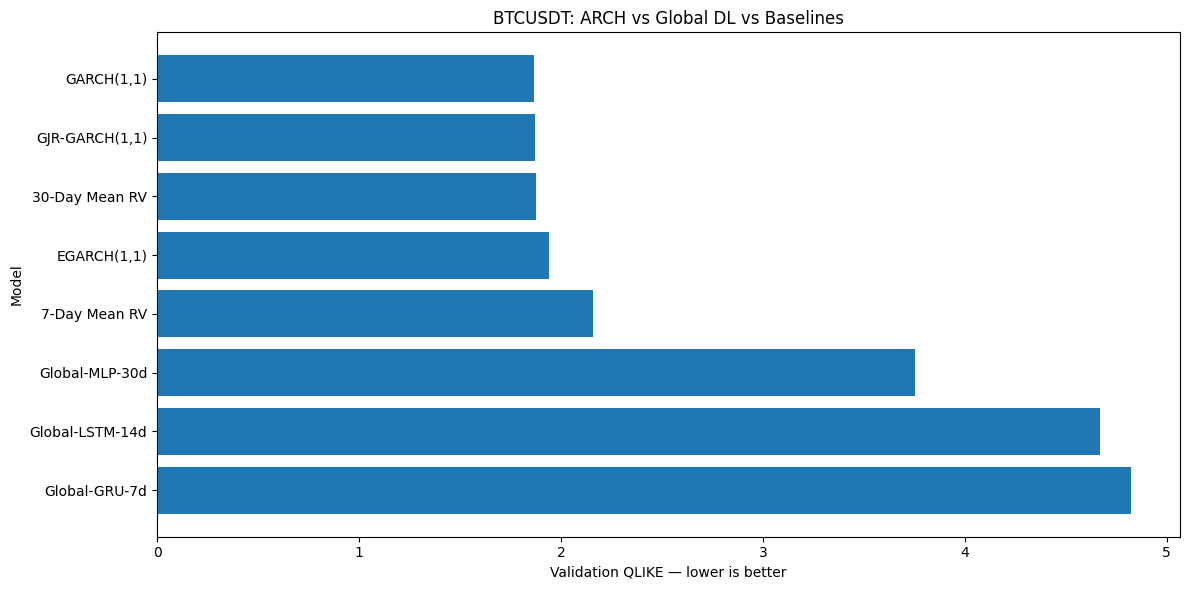

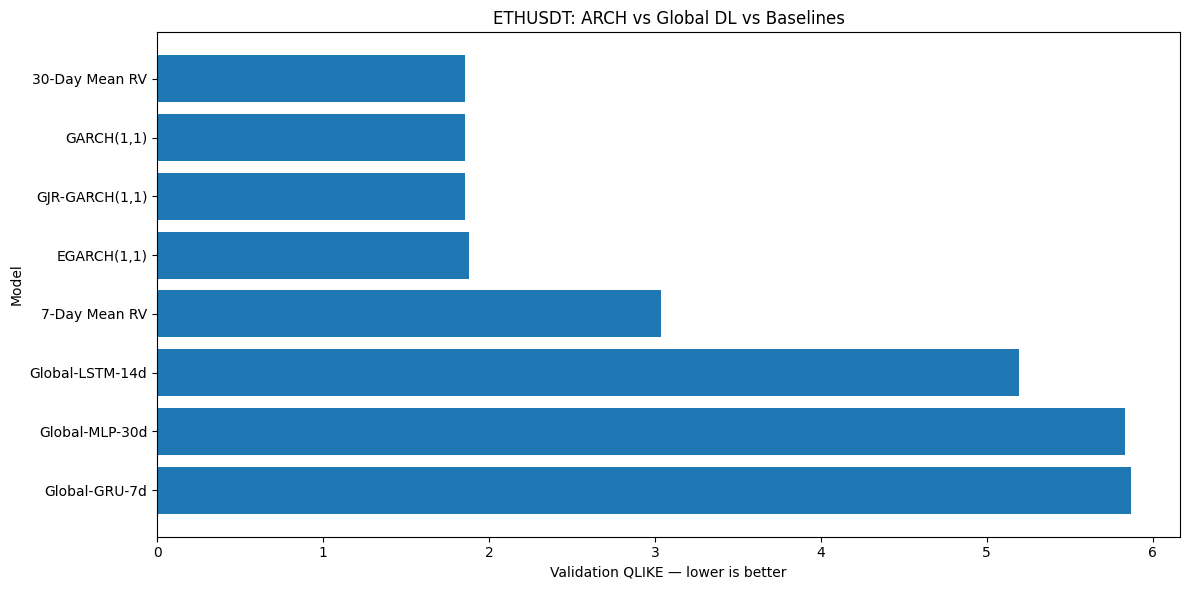

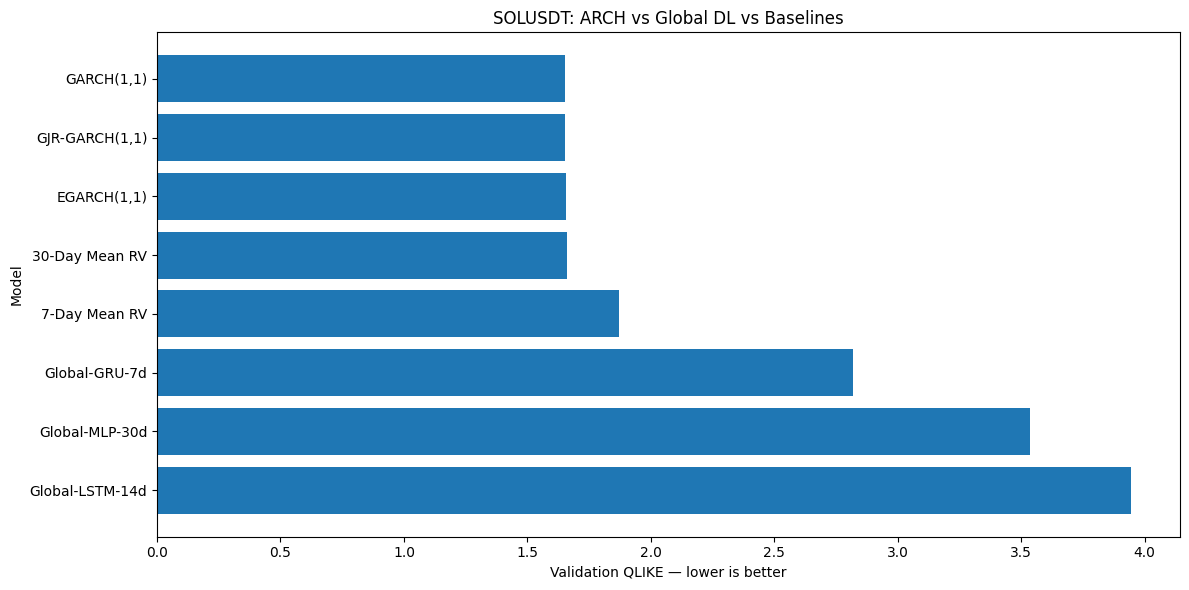

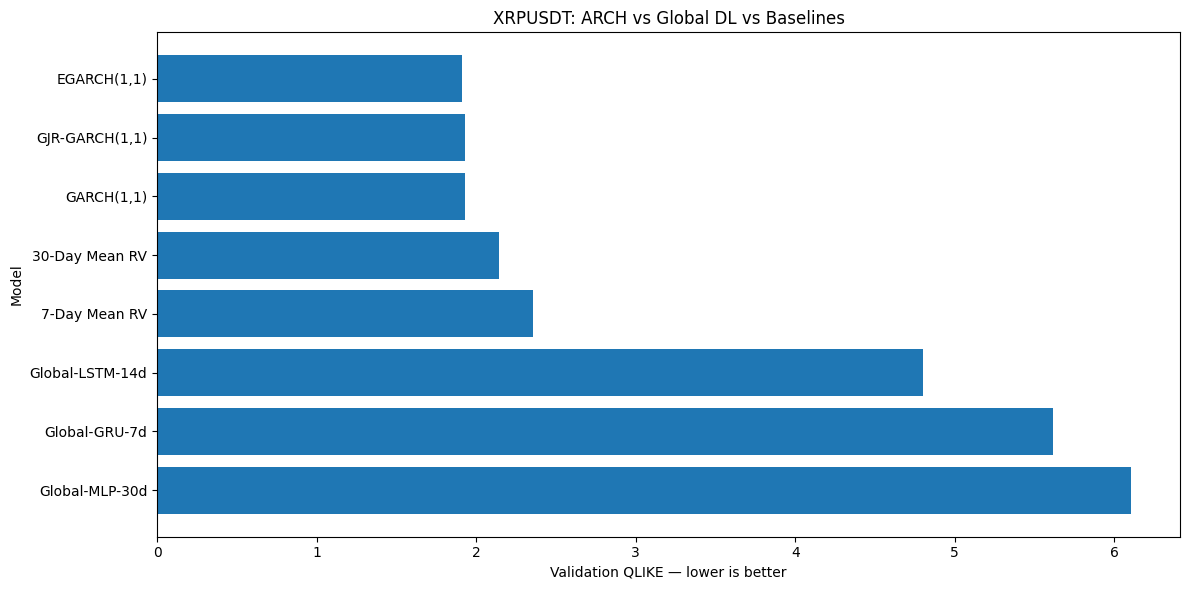

In [14]:
plot_df = (
    core_cross_asset_df.loc[
        ~core_cross_asset_df[
            "model"
        ].eq("Persistence")
    ]
    .copy()
)


for asset in CORE_ASSETS:

    asset_plot_df = (
        plot_df.loc[
            plot_df[
                "asset"
            ].eq(asset)
        ]
        .sort_values(
            "qlike",
            ascending=True,
        )
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.barh(
        asset_plot_df["model"],
        asset_plot_df["qlike"],
    )

    plt.xlabel("Validation QLIKE — lower is better")
    plt.ylabel("Model")
    plt.title(
        f"{asset}: ARCH vs Global DL vs Baselines"
    )

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 15. Final automated summary

In [15]:
print("=" * 72)
print("FINAL VALIDATION SUMMARY")
print("=" * 72)

for _, row in arch_vs_dl_df.iterrows():

    print(
        f"\n{row['asset']}:"
    )

    print(
        f"  Best ARCH      : "
        f"{row['best_arch_model']} "
        f"(QLIKE={row['best_arch_qlike']:.6f})"
    )

    print(
        f"  Best Global DL : "
        f"{row['best_global_dl_model']} "
        f"(QLIKE={row['best_global_dl_qlike']:.6f})"
    )

    print(
        f"  Best Baseline  : "
        f"{row['best_baseline_model']} "
        f"(QLIKE={row['best_baseline_qlike']:.6f})"
    )

    print(
        f"  Overall winner : "
        f"{row['overall_winner_model']} "
        f"[{row['overall_winner_scope']}]"
    )


print(
    "\nCross-asset ranking "
    "(excluding Persistence):"
)

display(
    cross_asset_summary_df[
        [
            "model",
            "source_scope",
            "mean_qlike",
            "mean_qlike_rank",
        ]
    ]
    .head(10)
)

FINAL VALIDATION SUMMARY

BTCUSDT:
  Best ARCH      : GARCH(1,1) (QLIKE=1.865873)
  Best Global DL : Global-MLP-30d (QLIKE=3.751286)
  Best Baseline  : 30-Day Mean RV (QLIKE=1.878815)
  Overall winner : GARCH(1,1) [ARCH]

ETHUSDT:
  Best ARCH      : GARCH(1,1) (QLIKE=1.855979)
  Best Global DL : Global-LSTM-14d (QLIKE=5.195097)
  Best Baseline  : 30-Day Mean RV (QLIKE=1.855280)
  Overall winner : 30-Day Mean RV [Baseline]

SOLUSDT:
  Best ARCH      : GARCH(1,1) (QLIKE=1.650260)
  Best Global DL : Global-GRU-7d (QLIKE=2.820048)
  Best Baseline  : 30-Day Mean RV (QLIKE=1.661597)
  Overall winner : GARCH(1,1) [ARCH]

XRPUSDT:
  Best ARCH      : EGARCH(1,1) (QLIKE=1.914143)
  Best Global DL : Global-LSTM-14d (QLIKE=4.802991)
  Best Baseline  : 30-Day Mean RV (QLIKE=2.145177)
  Overall winner : EGARCH(1,1) [ARCH]

Cross-asset ranking (excluding Persistence):


,model,source_scope,mean_qlike,mean_qlike_rank
0,"GARCH(1,1)",ARCH,1.825182,1.75
1,"GJR-GARCH(1,1)",ARCH,1.826857,2.25
2,"EGARCH(1,1)",ARCH,1.848306,3.00
3,30-Day Mean RV,Baseline,1.885217,3.00
4,7-Day Mean RV,Baseline,2.356060,5.00
5,Global-LSTM-14d,Global DL,4.652908,6.75
6,Global-MLP-30d,Global DL,4.806985,7.00
7,Global-GRU-7d,Global DL,4.782429,7.25


## Interpretation guide

Use the outputs in this order:

1. **`best_arch_vs_global_dl_vs_baseline.csv`** — primary high-level comparison for BTC, ETH, SOL and XRP.
2. **`best_model_by_asset_qlike.csv`** — winning model for each asset.
3. **`core_cross_asset_validation_comparison.csv`** — all directly comparable four-asset models.
4. **`btc_standalone_vs_global_dl.csv`** — standalone-vs-pooled DL evidence for BTC.
5. **`all_validation_model_metrics.csv`** — complete audit table containing every loaded model result.

### Metric interpretation

- **QLIKE:** primary volatility-forecasting metric; lower is better.
- **MAE:** average absolute variance error; lower is better.
- **RMSE:** penalizes larger variance misses more strongly; lower is better.

A model can have lower MAE but worse QLIKE. For the project conclusion, use QLIKE as the primary ranking criterion and use MAE/RMSE as supporting evidence.